# Knowledge-Based Appearance Recognition of Objects Using Classical AI

## Objective
This project demonstrates how a computer can recognize objects in images using classical Artificial Intelligence techniques, without Machine Learning or Deep Learning.

## Problem Statement
Given a folder of images, the system:
1. Processes every supported image file using classical image processing.
2. Detects candidate objects and measures shape, color, and size.
3. Converts measurements into symbolic facts.
4. Compares facts against a hand-built Knowledge Base using explicit production rules and a weighted closest-match fallback.
5. Reports each image's recognition result and explanation, and saves a CSV summary.

## Why Classical AI?
- No neural networks, pretrained classifiers, training data, or gradient descent are used.
- Recognition comes from explicit human-authored knowledge and rules.
- Decisions can be traced to readable rules, following explainable symbolic AI and expert systems.

## What's Included
- Folder-based batch processing for PNG, JPG, JPEG, BMP, TIF, and TIFF images.
- Multi-object contour handling within each image.
- An extensible knowledge base with explicit object rules.
- Exact matching, weighted similarity fallback, and a CSV batch report.

## Pipeline Overview
```
Image Folder → Batch Image Loading → Per-Image Perception and Segmentation
→ Multi-Object Contour Detection → Feature Extraction → Symbolic Facts
→ Knowledge Base and Production Rules → Explainable Recognition → CSV Summary
```

In [1]:
# Import required libraries
# OpenCV  -> used ONLY for classical image processing / perception (no ML models)
# NumPy   -> numerical operations on pixel arrays
# Matplotlib -> displaying images at every stage

import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")
print("OpenCV version:", cv2.__version__)


Libraries imported successfully.
OpenCV version: 5.0.0


## Stage 1: Input Acquisition

The system processes every supported image in a selected folder. The folder path is configured once, and the first image is also used to illustrate the perception stages below. Batch results for the full folder are reported in Stage 15.

In [2]:
# ---------------------------------------------------------
# STEP: Select a folder of images for batch recognition
# ---------------------------------------------------------
from pathlib import Path

IMAGE_FOLDER = Path("D:\Projects\AI PROJECT\synthetic_object_dataset")
SUPPORTED_IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

folder_image_paths = sorted(
    path for path in IMAGE_FOLDER.rglob("*")
    if path.is_file() and path.suffix.lower() in SUPPORTED_IMAGE_EXTENSIONS
)
if not folder_image_paths:
    raise FileNotFoundError(
        f"No supported images found in '{IMAGE_FOLDER}'. Add images or change IMAGE_FOLDER."
    )

IMAGE_PATH = str(folder_image_paths[0])
print(f"Configured image folder: {IMAGE_FOLDER}")
print(f"Images found: {len(folder_image_paths)}")
print(f"First image used for the walkthrough: {IMAGE_PATH}")

Configured image folder: D:\Projects\AI PROJECT\synthetic_object_dataset
Images found: 12
First image used for the walkthrough: D:\Projects\AI PROJECT\synthetic_object_dataset\black_rectangle_medium.png


<>:6: SyntaxWarning: invalid escape sequence '\P'
<>:6: SyntaxWarning: invalid escape sequence '\P'
C:\Users\sabar\AppData\Local\Temp\ipykernel_25024\4128906892.py:6: SyntaxWarning: invalid escape sequence '\P'
  IMAGE_FOLDER = Path("D:\Projects\AI PROJECT\synthetic_object_dataset")


## Stage 2: Visual Perception (Loading and Displaying the Input)

Before any reasoning can happen, the system must "perceive" the raw image the same way a camera or eye would capture light — as a grid of pixel values.

Here we simply **read the image from disk** and display it, so we (and the audience) can see exactly what the AI system is working with.


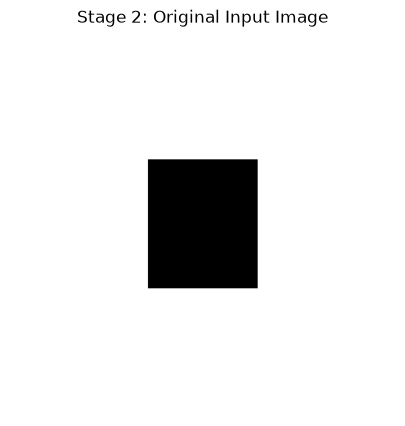

Image loaded successfully. Shape (Height, Width, Channels): (600, 600, 3)


In [3]:
# ---------------------------------------------------------
# STEP: Read and display the original input image
# ---------------------------------------------------------
import os

if not os.path.exists(IMAGE_PATH):
    raise FileNotFoundError(
        f"Input image not found at '{IMAGE_PATH}'. "
        "Please place an image in the notebook folder and update IMAGE_PATH."
    )

original_image = cv2.imread(IMAGE_PATH)

if original_image is None:
    raise ValueError(
        f"OpenCV could not read the image at '{IMAGE_PATH}'. "
        "Make sure the file is a valid image (jpg/png)."
    )

# OpenCV loads images in BGR order; convert to RGB for correct display with matplotlib
original_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 5))
plt.imshow(original_rgb)
plt.title("Stage 2: Original Input Image")
plt.axis("off")
plt.show()

print("Image loaded successfully. Shape (Height, Width, Channels):", original_image.shape)


## Stage 3: Grayscale Conversion (Preprocessing)

Color information is not needed for detecting shape and structure. Converting to grayscale:
- Reduces the image to a single intensity channel.
- Makes subsequent steps (blurring, thresholding, contour detection) simpler and faster.
- Is a classical, deterministic pixel-wise transformation — not a learned operation.


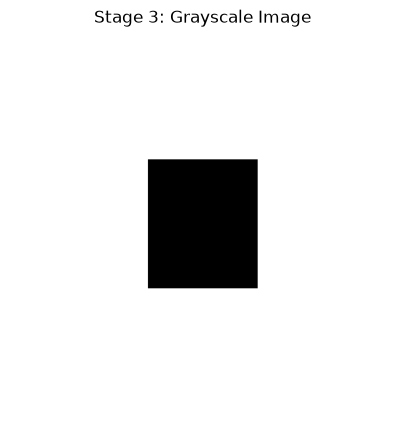

In [4]:
# ---------------------------------------------------------
# STEP: Convert to grayscale
# ---------------------------------------------------------
gray_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(5, 5))
plt.imshow(gray_image, cmap="gray")
plt.title("Stage 3: Grayscale Image")
plt.axis("off")
plt.show()


## Stage 4: Noise Reduction

Real-world images contain small pixel-level noise from lighting, compression, or sensor imperfections.

A **Gaussian blur** is a classical smoothing filter that averages neighboring pixels using a weighted (bell-curve) kernel. This suppresses noise while keeping the overall object edges recognizable, which improves the reliability of the thresholding step that follows.


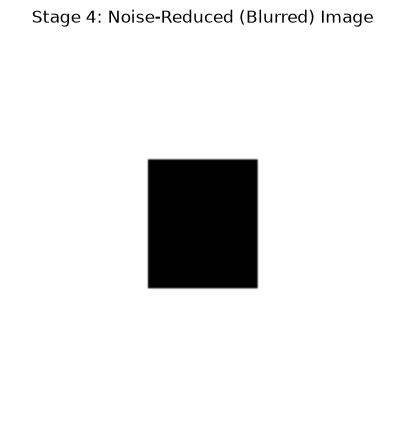

In [5]:
# ---------------------------------------------------------
# STEP: Apply Gaussian Blur for noise reduction
# ---------------------------------------------------------
blurred_image = cv2.GaussianBlur(gray_image, (5, 5), 0)

plt.figure(figsize=(5, 5))
plt.imshow(blurred_image, cmap="gray")
plt.title("Stage 4: Noise-Reduced (Blurred) Image")
plt.axis("off")
plt.show()


## Stage 5: Object Segmentation using Thresholding

**Segmentation** separates the object(s) of interest (foreground) from the background.

**Otsu's thresholding** is a classical statistical technique that automatically calculates the optimal threshold intensity value by analyzing the image's histogram, splitting pixels into two classes (object vs. background) that minimize the combined within-class variance. It requires no training data — only the pixel intensity distribution of this one image.


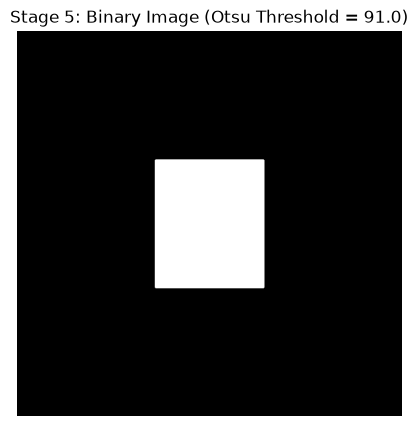

In [6]:
# ---------------------------------------------------------
# STEP: Apply Otsu's Thresholding
# ---------------------------------------------------------
threshold_value, binary_image = cv2.threshold(
    blurred_image, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

plt.figure(figsize=(5, 5))
plt.imshow(binary_image, cmap="gray")
plt.title(f"Stage 5: Binary Image (Otsu Threshold = {threshold_value:.1f})")
plt.axis("off")
plt.show()


## Stage 6: Morphological Image Processing

Thresholding can leave small holes inside objects or tiny noise specks outside them.

- **Opening** (erosion followed by dilation) removes small noise specks in the background.
- **Closing** (dilation followed by erosion) fills small holes inside objects.

Both are classical, rule-based, deterministic operations on pixel neighborhoods — they use no learned parameters.


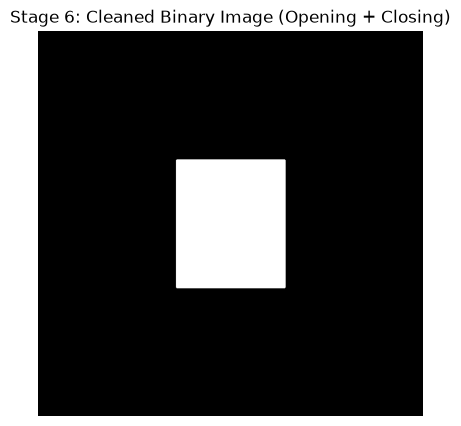

In [7]:
# ---------------------------------------------------------
# STEP: Morphological Opening and Closing
# ---------------------------------------------------------
kernel = np.ones((5, 5), np.uint8)

opened_image = cv2.morphologyEx(binary_image, cv2.MORPH_OPEN, kernel)
cleaned_image = cv2.morphologyEx(opened_image, cv2.MORPH_CLOSE, kernel)

plt.figure(figsize=(5, 5))
plt.imshow(cleaned_image, cmap="gray")
plt.title("Stage 6: Cleaned Binary Image (Opening + Closing)")
plt.axis("off")
plt.show()


## Stage 7: Contour Detection

A **contour** is a curve joining all continuous points along a boundary that share the same intensity. Contours give us a symbolic outline of candidate objects in the image — this is the bridge between "raw pixels" and "shapes we can reason about."


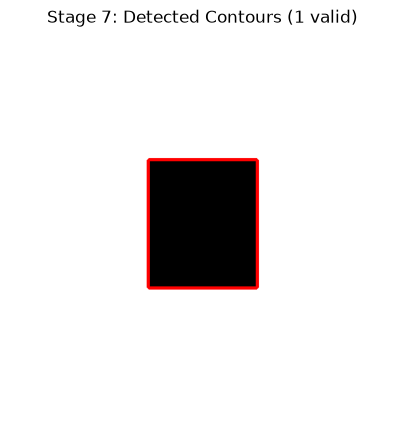

1 valid contour(s) found.


In [8]:
# ---------------------------------------------------------
# STEP: Detect contours and filter out tiny noise regions
# ---------------------------------------------------------
contours, _ = cv2.findContours(cleaned_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

MIN_CONTOUR_AREA = 500  # ignore very small regions (likely noise)
valid_contours = [c for c in contours if cv2.contourArea(c) > MIN_CONTOUR_AREA]

contour_display = original_rgb.copy()
cv2.drawContours(contour_display, valid_contours, -1, (255, 0, 0), 3)

plt.figure(figsize=(5, 5))
plt.imshow(contour_display)
plt.title(f"Stage 7: Detected Contours ({len(valid_contours)} valid)")
plt.axis("off")
plt.show()

if len(valid_contours) == 0:
    print("WARNING: No valid object contour was detected in this image.")
else:
    print(f"{len(valid_contours)} valid contour(s) found.")


## Stage 8: Multi-Object Handling

Earlier "single object" pipelines assume only the largest contour matters and discard everything else. That breaks down as soon as an image contains more than one object.

Here, **every valid contour becomes its own candidate object**. Each one will independently go through feature extraction, symbolic classification, and rule-based inference in the following stages, and each will get its own recognition result at the end. Objects are simply sorted largest-to-smallest so the biggest/most prominent object is discussed first, but none are discarded.


In [9]:
# ---------------------------------------------------------
# STEP: Register every valid contour as a separate candidate object
# ---------------------------------------------------------
detected_objects = []

sorted_contours = sorted(valid_contours, key=cv2.contourArea, reverse=True)

for idx, cnt in enumerate(sorted_contours):
    detected_objects.append({
        "id": idx,
        "contour": cnt,
        "area": cv2.contourArea(cnt),
    })

print(f"Total candidate objects registered: {len(detected_objects)}")
for obj in detected_objects:
    print(f"  Object {obj['id']}: area = {obj['area']:.2f} sq. pixels")


Total candidate objects registered: 1
  Object 0: area = 33998.00 sq. pixels


## Stage 9: Feature Extraction (Per Object)

This is where each object stops being just "a blob of pixels" and starts becoming **measurable, symbolic information** that a rule-based system can reason about — area, perimeter, shape, and proportions. This is now done independently for every candidate object found in Stage 8.


In [10]:
# ---------------------------------------------------------
# STEP: Extract geometric features for every candidate object
# ---------------------------------------------------------
for obj in detected_objects:
    cnt = obj["contour"]
    area = obj["area"]
    perimeter = cv2.arcLength(cnt, True)
    x, y, w, h = cv2.boundingRect(cnt)
    aspect_ratio = w / float(h) if h != 0 else 0

    approx_vertices = cv2.approxPolyDP(cnt, 0.03 * perimeter, True)
    num_vertices = len(approx_vertices)

    circularity = (4 * np.pi * area) / (perimeter ** 2) if perimeter != 0 else 0

    obj["features"] = {
        "area": area,
        "perimeter": perimeter,
        "bounding_box": (x, y, w, h),
        "width": w,
        "height": h,
        "aspect_ratio": aspect_ratio,
        "num_vertices": num_vertices,
        "circularity": circularity,
    }

for obj in detected_objects:
    print(f"Object {obj['id']} features:")
    for key, value in obj["features"].items():
        print(f"    {key:15s}: {value}")


Object 0 features:
    area           : 33998.0
    perimeter      : 737.6568541526794
    bounding_box   : (215, 200, 171, 201)
    width          : 171
    height         : 201
    aspect_ratio   : 0.8507462686567164
    num_vertices   : 4
    circularity    : 0.7851533161393948


## Stage 10: Shape Recognition using Polygon Approximation

`cv2.approxPolyDP` approximates each contour as a polygon with fewer vertices. Classical geometric rules classify shapes from vertex count, aspect ratio, and circularity:

- 3 vertices → Triangle
- 4 vertices, aspect ratio near 1 → Square
- 4 vertices, other aspect ratio → Rectangle
- 6 vertices → Hexagon
- High circularity with many vertices and near-equal dimensions → Circle
- High circularity with many vertices and elongated dimensions → Oval
- Otherwise → Unknown / Complex shape

In [11]:
# ---------------------------------------------------------
# STEP: Classify shape using classical geometric rules (per object)
# ---------------------------------------------------------
def classify_shape(num_vertices, aspect_ratio, circularity):
    if circularity > 0.8 and num_vertices > 6:
        if 0.85 <= aspect_ratio <= 1.15:
            return "circle"
        return "oval"
    if num_vertices == 3:
        return "triangle"
    if num_vertices == 4:
        if 0.90 <= aspect_ratio <= 1.10:
            return "square"
        return "rectangle"
    if num_vertices == 6:
        return "hexagon"
    return "unknown"


for obj in detected_objects:
    features = obj["features"]
    obj["shape"] = classify_shape(
        features["num_vertices"], features["aspect_ratio"], features["circularity"]
    )

for obj in detected_objects:
    print(f"Object {obj['id']}: rule-based shape classification -> '{obj['shape']}'")

Object 0: rule-based shape classification -> 'rectangle'


## Stage 11: Color Feature Extraction

Numeric pixel color values are converted into a **symbolic color label** (e.g. "red", "blue") using manually defined HSV ranges, computed separately over each object's own contour mask. HSV (Hue-Saturation-Value) is used instead of RGB because Hue represents color identity independently of brightness, making rule thresholds more reliable.


In [12]:
# ---------------------------------------------------------
# STEP: Extract mean color and classify it symbolically (per object)
# ---------------------------------------------------------
def classify_color(h, s, v):
    if v < 50:
        return "black"
    if s < 40 and v > 200:
        return "white"
    if s < 40:
        return "gray"
    if h >= 170 and s < 120:
        return "pink"
    if h < 10 or h >= 170:
        return "red"
    if 10 <= h < 25:
        return "orange"
    if 25 <= h < 35:
        return "yellow"
    if 35 <= h < 85:
        return "green"
    if 85 <= h < 100:
        return "cyan"
    if 100 <= h < 130:
        return "blue"
    if 130 <= h < 170:
        return "purple"
    return "unknown"


hsv_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2HSV)

for obj in detected_objects:
    mask = np.zeros(gray_image.shape, dtype=np.uint8)
    cv2.drawContours(mask, [obj["contour"]], -1, 255, thickness=cv2.FILLED)

    mean_h, mean_s, mean_v, _ = cv2.mean(hsv_image, mask=mask)
    obj["mean_hsv"] = (mean_h, mean_s, mean_v)
    obj["color"] = classify_color(mean_h, mean_s, mean_v)

for obj in detected_objects:
    mh, ms, mv = obj["mean_hsv"]
    print(f"Object {obj['id']}: mean HSV=({mh:.1f}, {ms:.1f}, {mv:.1f}) -> color '{obj['color']}'")

Object 0: mean HSV=(0.0, 0.0, 0.0) -> color 'black'


## Stage 12: Size Classification

Each object's bounding-box extent is measured as a fraction of the image dimensions and mapped to tiny, small, medium, or large using explicit thresholds. Normalizing by image dimensions makes the rule usable across image resolutions.

In [13]:
# ---------------------------------------------------------
# STEP: Classify object size relative to the image dimensions
# ---------------------------------------------------------
def classify_size(bounding_box, image_shape):
    _, _, width, height = bounding_box
    image_height, image_width = image_shape[:2]
    relative_extent = max(width / image_width, height / image_height)

    if relative_extent <= 0.13:
        return "tiny"
    if relative_extent <= 0.25:
        return "small"
    if relative_extent <= 0.34:
        return "medium"
    return "large"


for obj in detected_objects:
    obj["size"] = classify_size(obj["features"]["bounding_box"], gray_image.shape)

for obj in detected_objects:
    print(f"Object {obj['id']}: normalized size classification -> '{obj['size']}'")

Object 0: normalized size classification -> 'medium'


## Stage 13: Knowledge Representation

This is the core of the classical-AI component. The system matches observed symbolic facts against human-authored knowledge; it does not learn object descriptions from data.

The knowledge base contains 13 explicit color, shape, and size rules, including Cyan Hexagon. Use the `add_knowledge_rule(name, color, shape, size)` helper in the following code cell to append additional rules.

In [14]:
# ---------------------------------------------------------
# STEP: Define the extensible Knowledge Base and production rules
# ---------------------------------------------------------
knowledge_base = [
    {"name": "Red Ball", "color": "red", "shape": "circle", "size": "small", "aliases": ["red", "orange"]},
    {"name": "Blue Box", "color": "blue", "shape": "square", "size": "medium", "aliases": ["blue", "cyan"]},
    {"name": "Green Triangle", "color": "green", "shape": "triangle", "size": "small", "aliases": ["green"]},
    {"name": "Yellow Rectangle", "color": "yellow", "shape": "rectangle", "size": "large", "aliases": ["yellow", "orange"]},
    {"name": "Orange Ball", "color": "orange", "shape": "circle", "size": "medium", "aliases": ["orange", "yellow", "red"]},
    {"name": "Purple Box", "color": "purple", "shape": "square", "size": "small", "aliases": ["purple", "blue"]},
    {"name": "White Circle", "color": "white", "shape": "circle", "size": "large", "aliases": ["white", "gray"]},
    {"name": "Black Rectangle", "color": "black", "shape": "rectangle", "size": "medium", "aliases": ["black", "gray"]},
    {"name": "Gray Triangle", "color": "gray", "shape": "triangle", "size": "medium", "aliases": ["gray", "white", "black"]},
    {"name": "Red Rectangle", "color": "red", "shape": "rectangle", "size": "small", "aliases": ["red", "orange"]},
    {"name": "Blue Cylinder", "color": "blue", "shape": "circle", "size": "medium", "aliases": ["blue", "purple"]},
    {"name": "Green Square", "color": "green", "shape": "square", "size": "medium", "aliases": ["green"]},
]

production_rules = []


def add_new_object_to_knowledge_base(object_name, color, shape, size):
    values = {
        "object_name": object_name,
        "color": color,
        "shape": shape,
        "size": size,
    }
    if any(not isinstance(value, str) or not value.strip() for value in values.values()):
        raise ValueError("Object name, color, shape, and size must be non-empty strings.")

    object_name = object_name.strip()
    color = color.strip().lower()
    shape = shape.strip().lower()
    size = size.strip().lower()
    if size not in {"tiny", "small", "medium", "large"}:
        raise ValueError("Size must be one of: tiny, small, medium, large.")

    properties = {"color": color, "shape": shape, "size": size}
    existing_object = next(
        (entry for entry in knowledge_base if entry["name"].casefold() == object_name.casefold()),
        None,
    )
    if existing_object and any(existing_object[key] != value for key, value in properties.items()):
        raise ValueError(f"'{object_name}' already exists with different properties.")

    rule_name = f"{object_name} Rule"
    existing_rule = next((rule for rule in production_rules if rule["name"] == rule_name), None)
    if existing_rule and (
        existing_rule["conditions"] != properties or existing_rule["result"] != object_name
    ):
        raise ValueError(f"Production rule '{rule_name}' already exists with different conditions.")

    if existing_object is None:
        existing_object = {"name": object_name, **properties, "aliases": [color]}
        knowledge_base.append(existing_object)

    if existing_rule is None:
        production_rules.append({
            "name": rule_name,
            "conditions": properties.copy(),
            "result": object_name,
        })

    print("Knowledge acquired successfully.")
    print(f"Object added: {object_name}")
    print(f"Properties:\nColor: {color}\nShape: {shape}\nSize: {size}")
    print(f"Production rule added: {rule_name}")
    return existing_object


def add_knowledge_rule(name, color, shape, size):
    return add_new_object_to_knowledge_base(name, color, shape, size)


def generate_default_object_name(facts):
    color = str(facts.get("color", "")).strip().title()
    shape = str(facts.get("shape", "")).strip().title()
    size = str(facts.get("size", "")).strip().title()

    if not color or not shape or not size:
        raise ValueError(f"Facts are incomplete for object naming: {facts}")

    return f"{color} {shape}"


def identify_or_acquire_object(facts, object_name=None, ask_for_confirmation=True):
    matched_rule = match_production_rule(facts)
    if matched_rule is not None:
        return {
            "status": "known",
            "label": matched_rule["result"],
            "acquired": False,
            "rule": matched_rule,
        }

    chosen_name = (object_name or generate_default_object_name(facts)).strip()
    if ask_for_confirmation:
        answer = input(
            f"Object '{chosen_name}' with facts {facts} is not in the knowledge base. "
            "Add it to the knowledge base? [y/N]: "
        ).strip().lower()
        if answer not in {"y", "yes"}:
            return {
                "status": "unknown",
                "label": "Unknown Object",
                "acquired": False,
                "rule": None,
            }

    add_new_object_to_knowledge_base(
        chosen_name,
        facts["color"],
        facts["shape"],
        facts["size"],
    )
    return {
        "status": "new",
        "label": chosen_name,
        "acquired": True,
        "rule": match_production_rule(facts),
    }


for entry in knowledge_base:
    production_rules.append({
        "name": f"{entry['name']} Rule",
        "conditions": {
            "color": entry["color"],
            "shape": entry["shape"],
            "size": entry["size"],
        },
        "result": entry["name"],
    })

add_knowledge_rule("Cyan Hexagon", "cyan", "hexagon", "tiny")

print(f"Knowledge Base -- {len(knowledge_base)} entries; production rules -- {len(production_rules)}")


Knowledge acquired successfully.
Object added: Cyan Hexagon
Properties:
Color: cyan
Shape: hexagon
Size: tiny
Production rule added: Cyan Hexagon Rule
Knowledge Base -- 13 entries; production rules -- 13


## Stage 14: Fact Representation

The numeric measurements extracted for each detected object (Stages 10–12) are now converted into a **fact** — a simple symbolic statement about *that specific observed object* — in the same vocabulary (color / shape / size) as the Knowledge Base, so the two can be compared directly.


In [15]:
# ---------------------------------------------------------
# STEP: Build the observed facts dictionary for every object
# ---------------------------------------------------------
for obj in detected_objects:
    obj["facts"] = {
        "color": obj["color"],
        "shape": obj["shape"],
        "size": obj["size"],
    }

print("Observed Facts (extracted from the image), per object:")
for obj in detected_objects:
    print(f"  Object {obj['id']}: {obj['facts']}")


Observed Facts (extracted from the image), per object:
  Object 0: {'color': 'black', 'shape': 'rectangle', 'size': 'medium'}


## Stage 15: Production Rules and IF–THEN Reasoning

The system first evaluates explicit IF–THEN production rules against symbolic facts.

**Primary rule — exact symbolic match:**
```
IF observed.color == rule.conditions.color
AND observed.shape == rule.conditions.shape
AND observed.size  == rule.conditions.size
THEN return rule.result
```

If no exact rule matches, the existing weighted similarity fallback may report a close candidate when its score passes the threshold. The fallback is secondary; newly acquired knowledge is recognized by an explicit production rule, not by a learned classifier.

The `production_rules` list contains a rule for each known object and can be extended at runtime when a knowledge engineer adds an object.

In [16]:
# ---------------------------------------------------------
# STEP: Symbolic production-rule inference with optional fuzzy fallback
# ---------------------------------------------------------
# Exact production rules are the primary reasoning mechanism.
def match_production_rule(facts, rules=None):
    rules = production_rules if rules is None else rules
    for rule in rules:
        conditions = rule["conditions"]
        if all(facts.get(attribute) == value for attribute, value in conditions.items()):
            return rule
    return None


def infer_symbolic_facts(facts, rules=None):
    matched_rule = match_production_rule(facts, rules)
    return matched_rule["result"] if matched_rule else "Unknown Object"


def color_similarity(obs_color, kb_color):
    if obs_color == kb_color:
        return 1.0

    color_groups = {
        "red": {"red", "orange"},
        "orange": {"orange", "yellow", "red"},
        "yellow": {"yellow", "orange", "green"},
        "green": {"green", "yellow", "blue"},
        "blue": {"blue", "cyan", "purple", "green"},
        "cyan": {"cyan", "blue"},
        "purple": {"purple", "blue", "red"},
        "white": {"white", "gray"},
        "black": {"black", "gray", "white"},
        "gray": {"gray", "black", "white"},
    }

    if kb_color in color_groups.get(obs_color, set()):
        return 0.75
    if obs_color in color_groups.get(kb_color, set()):
        return 0.75
    return 0.0


def shape_similarity(obs_shape, kb_shape):
    if obs_shape == kb_shape:
        return 1.0
    if obs_shape in {"square", "rectangle"} and kb_shape in {"square", "rectangle"}:
        return 0.85
    if obs_shape in {"triangle", "rectangle"} and kb_shape in {"triangle", "rectangle"}:
        return 0.55
    return 0.0


def size_similarity(obs_size, kb_size):
    if obs_size == kb_size:
        return 1.0

    size_order = ["tiny", "small", "medium", "large"]
    if obs_size not in size_order or kb_size not in size_order:
        return 0.0

    difference = abs(size_order.index(obs_size) - size_order.index(kb_size))
    return 0.70 if difference == 1 else 0.0


def run_inference_engine(facts, kb, rules=None):
    rules = production_rules if rules is None else rules
    results = []
    for entry in kb:
        obs_color = facts["color"]
        obs_shape = facts["shape"]
        obs_size = facts["size"]
        kb_color = entry["color"]
        kb_shape = entry["shape"]
        kb_size = entry["size"]

        color_score = color_similarity(obs_color, kb_color)
        shape_score = shape_similarity(obs_shape, kb_shape)
        size_score = size_similarity(obs_size, kb_size)
        weighted_score = (0.45 * color_score) + (0.35 * shape_score) + (0.20 * size_score)
        matched_rule = match_production_rule(facts, rules)
        exact_match = matched_rule is not None and matched_rule["result"] == entry["name"]

        results.append({
            "object": entry["name"],
            "matched_rule": matched_rule["name"] if exact_match else None,
            "color_similarity": color_score,
            "shape_similarity": shape_score,
            "size_similarity": size_score,
            "weighted_score": weighted_score,
            "exact_match": exact_match,
            "color_match": obs_color == kb_color,
            "shape_match": obs_shape == kb_shape,
            "size_match": obs_size == kb_size,
        })
    return results


def decide(results):
    if not results:
        return {
            "mode": "none",
            "result": None,
            "mismatched": ["color", "shape", "size"],
            "confidence": 0.0,
            "match_count": 0,
        }

    exact_matches = [result for result in results if result["exact_match"]]
    if exact_matches:
        best = max(exact_matches, key=lambda result: result["weighted_score"])
        return {
            "mode": "exact",
            "result": best,
            "confidence": 1.0,
            "match_count": 3,
        }

    best = max(results, key=lambda result: result["weighted_score"])
    mismatched = [
        attribute
        for attribute in ("color", "shape", "size")
        if not best[f"{attribute}_match"]
    ]
    if best["weighted_score"] >= 0.60:
        return {
            "mode": "partial",
            "result": best,
            "mismatched": mismatched,
            "confidence": round(best["weighted_score"], 2),
            "match_count": 3 - len(mismatched),
        }

    return {
        "mode": "none",
        "result": None,
        "mismatched": mismatched,
        "confidence": round(best["weighted_score"], 2),
        "match_count": 0,
    }


for obj in detected_objects:
    obj["inference_results"] = run_inference_engine(obj["facts"], knowledge_base)
    obj["decision"] = decide(obj["inference_results"])

    decision = obj["decision"]
    if decision["mode"] == "exact":
        print(f"Object {obj['id']}: EXACT MATCH -> {decision['result']['object']} (confidence=1.00; rule={decision['result']['matched_rule']})")
    elif decision["mode"] == "partial":
        print(
            f"Object {obj['id']}: CLOSEST MATCH -> {decision['result']['object']} "
            f"(confidence={decision['confidence']:.2f}; differs on: {', '.join(decision['mismatched'])})"
        )
    else:
        print(f"Object {obj['id']}: NO STRONG MATCH (confidence={decision['confidence']:.2f})")

Object 0: EXACT MATCH -> Black Rectangle (confidence=1.00; rule=Black Rectangle Rule)


## Knowledge Acquisition – Adding a New Object to the Knowledge Base

The system does **not** learn a new object from training data and does not retrain. A knowledge engineer manually adds the object name, its color, shape, and size, plus a corresponding IF–THEN production rule. The existing perception algorithm remains unchanged.

| Responsibility | What happens |
| --- | --- |
| **Perception** | OpenCV extracts visual properties and converts them to symbolic facts. |
| **Knowledge** | The Knowledge Base stores known object descriptions. |
| **Reasoning** | Production rules match symbolic facts to a known object. |
| **Knowledge acquisition** | A knowledge engineer adds a new object and its rule. |

The Green Cylinder demonstration starts at the symbolic-fact boundary with representative facts `green`, `cylinder`, and `medium`. The current geometric perception rules do not classify cylinders from pixels, so that example isolates rule-based inference without modifying perception.

The separate `knowledge_acquisition_dataset` folder contains 36 images with facts absent from the starting Knowledge Base; `new_object_manifest.csv` lists their suggested names and properties. In the next cell, set `SELECTED_IMAGE_PATH` to one image. The notebook extracts its facts, shows the result before acquisition, adds only that image's object and rule, then explains the after result.

In [17]:
# ---------------------------------------------------------
# SEMINAR DEMO: Knowledge acquisition without retraining
# ---------------------------------------------------------
demo_facts = {
    "color": "green",
    "shape": "cylinder",
    "size": "medium",
}
demo_object_name = "Green Cylinder"

# Exclude the demo object from the baseline so rerunning this cell stays repeatable.
baseline_knowledge = [
    entry for entry in knowledge_base
    if entry["name"].casefold() != demo_object_name.casefold()
]
baseline_rules = [
    rule for rule in production_rules
    if rule["result"].casefold() != demo_object_name.casefold()
]

print("=" * 31)
print("KNOWLEDGE ACQUISITION DEMO")
print("=" * 31)
print("STEP 1: Representative symbolic facts at the perception/reasoning boundary")
print("Facts:")
print(f"  Color : {demo_facts['color']}")
print(f"  Shape : {demo_facts['shape']}")
print(f"  Size  : {demo_facts['size']}")
print("Note: the unchanged vision rules do not yet classify cylinders from pixels.")

print("\nSTEP 2: Inference before knowledge acquisition")
before_result = infer_symbolic_facts(demo_facts, baseline_rules)
print(f"  Inference Result: {before_result}")
assert before_result == "Unknown Object"

print("\nSTEP 3: Acquire new knowledge")
add_new_object_to_knowledge_base(
    demo_object_name,
    demo_facts["color"],
    demo_facts["shape"],
    demo_facts["size"],
)

print("\nSTEP 4: Corresponding production rule")
print("  IF color=green AND shape=cylinder AND size=medium")
print("  THEN object=Green Cylinder")

print("\nSTEP 5: Inference after knowledge acquisition")
after_result = infer_symbolic_facts(demo_facts)
print(f"  Inference Result: {after_result}")
assert after_result == demo_object_name
print("\nExplanation:")
print("The symbolic facts matched the newly added production rule.")
print("No retraining or perception-algorithm change was needed.")

KNOWLEDGE ACQUISITION DEMO
STEP 1: Representative symbolic facts at the perception/reasoning boundary
Facts:
  Color : green
  Shape : cylinder
  Size  : medium
Note: the unchanged vision rules do not yet classify cylinders from pixels.

STEP 2: Inference before knowledge acquisition
  Inference Result: Unknown Object

STEP 3: Acquire new knowledge
Knowledge acquired successfully.
Object added: Green Cylinder
Properties:
Color: green
Shape: cylinder
Size: medium
Production rule added: Green Cylinder Rule

STEP 4: Corresponding production rule
  IF color=green AND shape=cylinder AND size=medium
  THEN object=Green Cylinder

STEP 5: Inference after knowledge acquisition
  Inference Result: Green Cylinder

Explanation:
The symbolic facts matched the newly added production rule.
No retraining or perception-algorithm change was needed.


Novel images available: 36
  knowledge_acquisition_dataset\orange_triangle_medium.png -> Orange Triangle (orange, triangle, medium)
  knowledge_acquisition_dataset\red_hexagon_medium.png -> Red Hexagon (red, hexagon, medium)
  knowledge_acquisition_dataset\green_rectangle_large.png -> Green Rectangle (green, rectangle, large)
  knowledge_acquisition_dataset\yellow_circle_medium.png -> Yellow Circle (yellow, circle, medium)
  knowledge_acquisition_dataset\cyan_triangle_small.png -> Cyan Triangle (cyan, triangle, small)
  knowledge_acquisition_dataset\gray_square_large.png -> Gray Square (gray, square, large)
  knowledge_acquisition_dataset\black_circle_tiny.png -> Black Circle (black, circle, tiny)
  knowledge_acquisition_dataset\white_triangle_medium.png -> White Triangle (white, triangle, medium)
  knowledge_acquisition_dataset\pink_rectangle_small.png -> Pink Rectangle (pink, rectangle, small)
  knowledge_acquisition_dataset\orange_hexagon_large.png -> Orange Hexagon (orange, hexagon

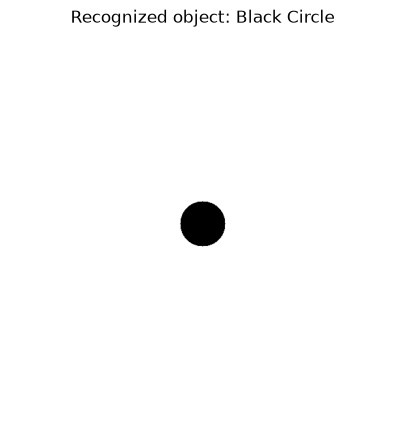

In [18]:
# ---------------------------------------------------------
# SEMINAR DEMO: Acquire one rule from a selected image
# ---------------------------------------------------------
import csv

NEW_RULE_IMAGE_FOLDER = Path("knowledge_acquisition_dataset")
manifest_path = NEW_RULE_IMAGE_FOLDER / "new_object_manifest.csv"
with manifest_path.open(newline="", encoding="utf-8") as manifest_file:
    new_object_examples = list(csv.DictReader(manifest_file))

print(f"Novel images available: {len(new_object_examples)}")
for row in new_object_examples:
    print(
        f"  {NEW_RULE_IMAGE_FOLDER / row['filename']} -> {row['object_name']} "
        f"({row['color']}, {row['shape']}, {row['size']})"
    )

# Set this to the image you want to use for knowledge acquisition.
SELECTED_IMAGE_PATH = Path("knowledge_acquisition_dataset/black_circle_tiny.png")
# For an image not listed in the manifest, enter its object name here.
SELECTED_OBJECT_NAME = "Purple Rectangle Large"

selected_image_path = Path(SELECTED_IMAGE_PATH)
manifest_entry = next(
    (row for row in new_object_examples if row["filename"] == selected_image_path.name),
    None,
)
if manifest_entry is not None:
    selected_object_name = manifest_entry["object_name"]
else:
    selected_object_name = SELECTED_OBJECT_NAME.strip()
    if not selected_object_name:
        raise ValueError(
            "For an image outside the manifest, set SELECTED_OBJECT_NAME before running this cell."
        )

image = cv2.imread(str(selected_image_path))
if image is None:
    raise FileNotFoundError(f"Could not read selected image: {selected_image_path}")

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
_, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
morphology_kernel = np.ones((5, 5), np.uint8)
opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, morphology_kernel)
cleaned = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, morphology_kernel)
contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours = [contour for contour in contours if cv2.contourArea(contour) > 500]
if not contours:
    raise ValueError(f"No object contour detected in: {selected_image_path}")

contour = max(contours, key=cv2.contourArea)
perimeter = cv2.arcLength(contour, True)
x, y, width, height = cv2.boundingRect(contour)
aspect_ratio = width / float(height) if height else 0.0
polygon = cv2.approxPolyDP(contour, 0.03 * perimeter, True)
area = cv2.contourArea(contour)
circularity = (4 * np.pi * area) / (perimeter ** 2) if perimeter else 0.0
shape = classify_shape(len(polygon), aspect_ratio, circularity)

object_mask = np.zeros(gray.shape, dtype=np.uint8)
cv2.drawContours(object_mask, [contour], -1, 255, thickness=cv2.FILLED)
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
mean_h, mean_s, mean_v, _ = cv2.mean(hsv, mask=object_mask)
color = classify_color(mean_h, mean_s, mean_v)
size = classify_size((x, y, width, height), gray.shape)
selected_facts = {"color": color, "shape": shape, "size": size}

if manifest_entry is not None:
    expected_facts = {key: manifest_entry[key] for key in ("color", "shape", "size")}
    if selected_facts != expected_facts:
        raise AssertionError(
            f"Extracted facts {selected_facts} do not match the manifest {expected_facts}."
        )

print("\n" + "=" * 47)
print("SELECTED IMAGE KNOWLEDGE CHECK")
print("=" * 47)
print(f"Image path: {selected_image_path}")
print("Extracted symbolic facts:")
print(f"  Color : {selected_facts['color']}")
print(f"  Shape : {selected_facts['shape']}")
print(f"  Size  : {selected_facts['size']}")

matched_rule = match_production_rule(selected_facts)
if matched_rule is not None:
    print(f"Object already exists in the knowledge base: {matched_rule['result']}")
    print("No new knowledge acquisition was needed.")
    after_result = matched_rule["result"]
else:
    selected_object_name = selected_object_name or generate_default_object_name(selected_facts)
    print(f"Object not found in the knowledge base. Determining new knowledge as: {selected_object_name}")
    result = identify_or_acquire_object(selected_facts, selected_object_name, ask_for_confirmation=False)
    print(f"Status: {result['status']}")
    print(f"Label: {result['label']}")
    after_result = result['label']
    if result['acquired']:
        print("Explanation: the extracted symbolic facts were not present in the KB, so new knowledge was automatically acquired.")
    else:
        print("Explanation: acquisition was not performed because the object was already known or the user declined.")

plt.figure(figsize=(5, 5))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title(f"Recognized object: {after_result}")
plt.axis("off")
plt.show()

assert after_result == (matched_rule["result"] if matched_rule else selected_object_name)


In [19]:
# ---------------------------------------------------------
# AUTO-ADD NEW OBJECTS WHEN THEY DO NOT EXIST IN THE KB
# ---------------------------------------------------------

def process_image_if_absent(image_path, object_name=None, auto_add=True):
    """Process one image, check the KB, notify on a miss, and add it if allowed."""
    image_path = Path(image_path)
    image = cv2.imread(str(image_path))
    if image is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    kernel = np.ones((5, 5), np.uint8)
    opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    cleaned = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = [c for c in contours if cv2.contourArea(c) > 500]
    if not contours:
        raise ValueError(f"No valid contour found in: {image_path}")

    contour = max(contours, key=cv2.contourArea)
    perimeter = cv2.arcLength(contour, True)
    x, y, width, height = cv2.boundingRect(contour)
    aspect_ratio = width / float(height) if height else 0.0
    polygon = cv2.approxPolyDP(contour, 0.03 * perimeter, True)
    area = cv2.contourArea(contour)
    circularity = (4 * np.pi * area) / (perimeter ** 2) if perimeter else 0.0
    shape = classify_shape(len(polygon), aspect_ratio, circularity)

    mask = np.zeros(gray.shape, dtype=np.uint8)
    cv2.drawContours(mask, [contour], -1, 255, thickness=cv2.FILLED)
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    mean_h, mean_s, mean_v, _ = cv2.mean(hsv, mask=mask)
    color = classify_color(mean_h, mean_s, mean_v)
    size = classify_size((x, y, width, height), gray.shape)
    facts = {"color": color, "shape": shape, "size": size}

    matched_rule = match_production_rule(facts)
    if matched_rule is not None:
        print(f"Notification: {image_path.name} is already in the knowledge base as '{matched_rule['result']}'.")
        return {"status": "known", "label": matched_rule["result"], "facts": facts}

    if not auto_add:
        print(f"Notification: {facts} not found in the KB. Auto-add is disabled.")
        return {"status": "unknown", "label": "Unknown Object", "facts": facts}

    assigned_name = (object_name or generate_default_object_name(facts)).strip()
    print(f"Notification: {facts} not found in the KB. Adding '{assigned_name}' to the knowledge base.")
    result = identify_or_acquire_object(facts, assigned_name, ask_for_confirmation=False)
    print(f"Result: {result['status']} -> {result['label']}")
    return {
        "status": result["status"],
        "label": result["label"],
        "facts": facts,
        "acquired": result["acquired"],
    }


# Example usage with the generated unknown dataset image
unknown_image = Path("unknown_object_dataset/purple_rectangle_large.png")
result = process_image_if_absent(unknown_image, object_name="Black Circle Tiny", auto_add=True)
print("Final output:")
print(result)


Notification: {'color': 'purple', 'shape': 'rectangle', 'size': 'large'} not found in the KB. Adding 'Black Circle Tiny' to the knowledge base.
Knowledge acquired successfully.
Object added: Black Circle Tiny
Properties:
Color: purple
Shape: rectangle
Size: large
Production rule added: Black Circle Tiny Rule
Result: new -> Black Circle Tiny
Final output:
{'status': 'new', 'label': 'Black Circle Tiny', 'facts': {'color': 'purple', 'shape': 'rectangle', 'size': 'large'}, 'acquired': True}


In [20]:
# ---------------------------------------------------------
# STEP: Test symbolic rules and recognize a folder of images
# ---------------------------------------------------------
import csv

symbolic_test_dataset = [
    {"id": 1, "color": "red", "shape": "circle", "size": "small", "case_type": "exact"},
    {"id": 2, "color": "orange", "shape": "circle", "size": "medium", "case_type": "exact"},
    {"id": 3, "color": "purple", "shape": "square", "size": "medium", "case_type": "partial"},
    {"id": 4, "color": "cyan", "shape": "hexagon", "size": "tiny", "case_type": "exact"},
    {"id": 5, "color": "pink", "shape": "oval", "size": "medium", "case_type": "none"},
]

print("Symbolic rule checks:")
symbolic_correct = 0
for row in symbolic_test_dataset:
    facts = {key: row[key] for key in ("color", "shape", "size")}
    decision = decide(run_inference_engine(facts, knowledge_base))
    passed = decision["mode"] == row["case_type"]
    symbolic_correct += int(passed)
    label = decision["result"]["object"] if decision["result"] else "no match"
    print(f"  Case {row['id']}: {facts} -> {label} ({decision['mode']}; {'PASS' if passed else 'CHECK'})")


image_paths = sorted(
    path for path in IMAGE_FOLDER.rglob("*")
    if path.is_file() and path.suffix.lower() in SUPPORTED_IMAGE_EXTENSIONS
)
if not image_paths:
    raise FileNotFoundError(f"No supported images found in '{IMAGE_FOLDER}'.")

image_test_results = []
for image_path in image_paths:
    image = cv2.imread(str(image_path))
    if image is None:
        result = {
            "file": str(image_path.relative_to(IMAGE_FOLDER)),
            "facts": {},
            "label": "unreadable image",
            "mode": "error",
            "confidence": 0.0,
            "contours": 0,
        }
        image_test_results.append(result)
        print(f"  {result['file']}: could not read image")
        continue

    image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    image_blurred = cv2.GaussianBlur(image_gray, (5, 5), 0)
    _, image_binary = cv2.threshold(
        image_blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )
    image_kernel = np.ones((5, 5), np.uint8)
    image_opened = cv2.morphologyEx(image_binary, cv2.MORPH_OPEN, image_kernel)
    image_cleaned = cv2.morphologyEx(image_opened, cv2.MORPH_CLOSE, image_kernel)
    image_contours, _ = cv2.findContours(
        image_cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    image_contours = [contour for contour in image_contours if cv2.contourArea(contour) > 500]

    if not image_contours:
        result = {
            "file": str(image_path.relative_to(IMAGE_FOLDER)),
            "facts": {},
            "label": "no object detected",
            "mode": "detection_failed",
            "confidence": 0.0,
            "contours": 0,
        }
        image_test_results.append(result)
        print(f"  {result['file']}: no object contour detected")
        continue

    contour = max(image_contours, key=cv2.contourArea)
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)
    x, y, width, height = cv2.boundingRect(contour)
    aspect_ratio = width / float(height) if height else 0.0
    polygon = cv2.approxPolyDP(contour, 0.03 * perimeter, True)
    circularity = (4 * np.pi * area) / (perimeter ** 2) if perimeter else 0.0
    shape = classify_shape(len(polygon), aspect_ratio, circularity)

    object_mask = np.zeros(image_gray.shape, dtype=np.uint8)
    cv2.drawContours(object_mask, [contour], -1, 255, thickness=cv2.FILLED)
    image_hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    mean_h, mean_s, mean_v, _ = cv2.mean(image_hsv, mask=object_mask)
    color = classify_color(mean_h, mean_s, mean_v)
    size = classify_size((x, y, width, height), image_gray.shape)
    facts = {"color": color, "shape": shape, "size": size}
    decision = decide(run_inference_engine(facts, knowledge_base))
    label = decision["result"]["object"] if decision["result"] else "no match"

    result = {
        "file": str(image_path.relative_to(IMAGE_FOLDER)),
        "facts": facts,
        "label": label,
        "mode": decision["mode"],
        "confidence": decision["confidence"],
        "contours": len(image_contours),
    }
    image_test_results.append(result)
    print(
        f"  {result['file']}: facts={facts} -> {label} "
        f"({decision['mode']}, confidence={decision['confidence']:.2f}; "
        f"{len(image_contours)} contour(s))"
    )

report_path = IMAGE_FOLDER / "recognition_results.csv"
with report_path.open("w", newline="", encoding="utf-8") as report_file:
    fieldnames = ["file", "color", "shape", "size", "label", "mode", "confidence", "contours"]
    writer = csv.DictWriter(report_file, fieldnames=fieldnames)
    writer.writeheader()
    for result in image_test_results:
        facts = result["facts"]
        writer.writerow({
            "file": result["file"],
            "color": facts.get("color", ""),
            "shape": facts.get("shape", ""),
            "size": facts.get("size", ""),
            "label": result["label"],
            "mode": result["mode"],
            "confidence": result["confidence"],
            "contours": result["contours"],
        })

print("\nBatch summary:")
print(f"  Folder: {IMAGE_FOLDER}")
print(f"  Symbolic cases passed: {symbolic_correct}/{len(symbolic_test_dataset)}")
print(f"  Images processed: {len(image_test_results)}/{len(image_paths)}")
print(f"  Exact / partial / no match: "
      f"{sum(item.get('mode') == 'exact' for item in image_test_results)} / "
      f"{sum(item.get('mode') == 'partial' for item in image_test_results)} / "
      f"{sum(item.get('mode') == 'none' for item in image_test_results)}")
print(f"  CSV report: {report_path}")

Symbolic rule checks:
  Case 1: {'color': 'red', 'shape': 'circle', 'size': 'small'} -> Red Ball (exact; PASS)
  Case 2: {'color': 'orange', 'shape': 'circle', 'size': 'medium'} -> Orange Ball (exact; PASS)
  Case 3: {'color': 'purple', 'shape': 'square', 'size': 'medium'} -> Purple Box (partial; PASS)
  Case 4: {'color': 'cyan', 'shape': 'hexagon', 'size': 'tiny'} -> Cyan Hexagon (exact; PASS)
  Case 5: {'color': 'pink', 'shape': 'oval', 'size': 'medium'} -> no match (none; PASS)
  black_rectangle_medium.png: facts={'color': 'black', 'shape': 'rectangle', 'size': 'medium'} -> Black Rectangle (exact, confidence=1.00; 1 contour(s))
  blue_box_medium.png: facts={'color': 'blue', 'shape': 'square', 'size': 'medium'} -> Blue Box (exact, confidence=1.00; 1 contour(s))
  cyan_hexagon_tiny.png: facts={'color': 'cyan', 'shape': 'hexagon', 'size': 'tiny'} -> Cyan Hexagon (exact, confidence=1.00; 1 contour(s))
  gray_triangle_medium.png: facts={'color': 'gray', 'shape': 'triangle', 'size': 'medi

## Stage 16: Explainable AI Reasoning

A key strength of classical rule-based AI is **explainability**: every decision can be traced back to which conditions matched and which did not — unlike a "black box" ML/DL model. Below we print a full reasoning trace, per object, across every Knowledge Base entry, including whether the exact-match rule or the fallback rule fired.


In [21]:
# ---------------------------------------------------------
# STEP: Print detailed reasoning trace with confidence values
# ---------------------------------------------------------
for obj in detected_objects:
    print("=" * 70)
    print(f"REASONING TRACE -- Object {obj['id']}")
    print("=" * 70)
    print(f"Observed Color : {obj['facts']['color']}")
    print(f"Observed Shape : {obj['facts']['shape']}")
    print(f"Observed Size  : {obj['facts']['size']}")
    print("-" * 70)

    for result in obj["inference_results"]:
        print(f"Candidate: {result['object']}")
        print(f"   Color similarity : {result['color_similarity']:.2f}")
        print(f"   Shape similarity : {result['shape_similarity']:.2f}")
        print(f"   Size similarity  : {result['size_similarity']:.2f}")
        print(f"   Weighted score   : {result['weighted_score']:.2f}")
        print(f"   Decision         : {'EXACT MATCH' if result['exact_match'] else 'CLOSEST FAMILY MATCH'}")
        print("-" * 70)

    d = obj["decision"]
    if d["mode"] == "exact":
        print(f"FINAL RESULT for Object {obj['id']}: {d['result']['object']} (exact match, confidence=1.00)")
    elif d["mode"] == "partial":
        print(f"FINAL RESULT for Object {obj['id']}: {d['result']['object']} "
              f"(closest match, confidence={d['confidence']:.2f}; differs on: {', '.join(d['mismatched'])})")
    else:
        print(f"FINAL RESULT for Object {obj['id']}: No strong match found (confidence={d['confidence']:.2f})")
    print("=" * 70)
    print()


REASONING TRACE -- Object 0
Observed Color : black
Observed Shape : rectangle
Observed Size  : medium
----------------------------------------------------------------------
Candidate: Red Ball
   Color similarity : 0.00
   Shape similarity : 0.00
   Size similarity  : 0.70
   Weighted score   : 0.14
   Decision         : CLOSEST FAMILY MATCH
----------------------------------------------------------------------
Candidate: Blue Box
   Color similarity : 0.00
   Shape similarity : 0.85
   Size similarity  : 1.00
   Weighted score   : 0.50
   Decision         : CLOSEST FAMILY MATCH
----------------------------------------------------------------------
Candidate: Green Triangle
   Color similarity : 0.00
   Shape similarity : 0.55
   Size similarity  : 0.70
   Weighted score   : 0.33
   Decision         : CLOSEST FAMILY MATCH
----------------------------------------------------------------------
Candidate: Yellow Rectangle
   Color similarity : 0.00
   Shape similarity : 1.00
   Size simil

## Stage 17: Final Decision and Object Recognition

Having traced the reasoning process for every object, we now present the final, consolidated result: the original image with every recognized object outlined and labeled, plus each object's extracted features and reasoning outcome.


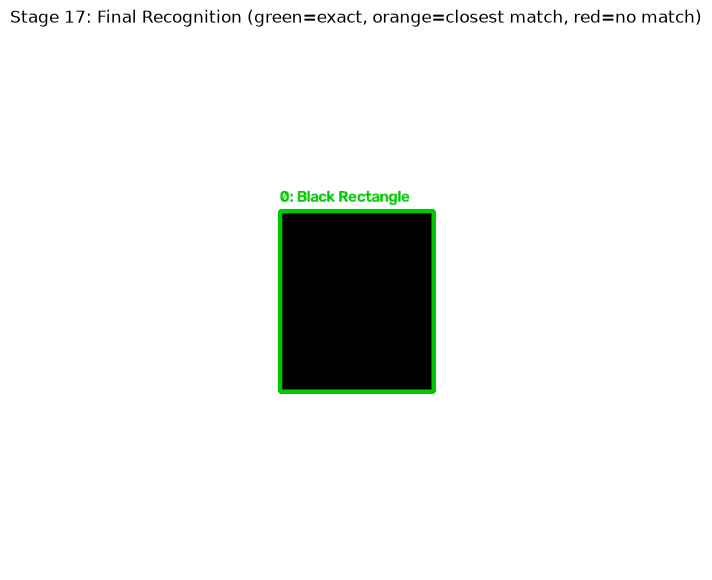

FINAL RECOGNITION SUMMARY:
  Object 0: Black Rectangle  [exact match]


In [22]:
# ---------------------------------------------------------
# STEP: Final summary display for all detected objects
# ---------------------------------------------------------
final_display = original_rgb.copy()

for obj in detected_objects:
    x, y, w, h = obj["features"]["bounding_box"]
    d = obj["decision"]

    if d["mode"] == "exact":
        label = d["result"]["object"]
        box_color = (0, 200, 0)       # green = exact match
    elif d["mode"] == "partial":
        label = f"{d['result']['object']}?"
        box_color = (255, 165, 0)     # orange = partial / closest match
    else:
        label = "no match"
        box_color = (200, 0, 0)       # red = no match

    cv2.rectangle(final_display, (x, y), (x + w, y + h), box_color, 3)
    cv2.putText(final_display, f"{obj['id']}: {label}", (x, max(y - 10, 15)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, box_color, 2)

plt.figure(figsize=(7, 7))
plt.imshow(final_display)
plt.title("Stage 17: Final Recognition (green=exact, orange=closest match, red=no match)")
plt.axis("off")
plt.show()

print("FINAL RECOGNITION SUMMARY:")
for obj in detected_objects:
    d = obj["decision"]
    if d["mode"] == "exact":
        print(f"  Object {obj['id']}: {d['result']['object']}  [exact match]")
    elif d["mode"] == "partial":
        print(f"  Object {obj['id']}: {d['result']['object']}  "
              f"[closest match, {d['match_count']}/3, differs on: {', '.join(d['mismatched'])}]")
    else:
        print(f"  Object {obj['id']}: no match found")

## Final Pipeline Summary

```
Selected Image Folder
   -> Load supported images (PNG/JPG/JPEG/BMP/TIF/TIFF)
   -> Process each image using preprocessing and segmentation
   -> Detect and classify candidate objects
   -> Build symbolic color / shape / size facts
   -> Apply 13 explicit knowledge-base entries and inference rules
   -> Report exact / partial / no-match outcomes per image
   -> Save recognition_results.csv in the selected folder
```

### Classical-AI Concepts
- **Knowledge Representation** — object descriptions are explicitly authored, not learned.
- **Production Rules** — exact matching and weighted fallback are human-defined and transparent.
- **Rule-Based Reasoning** — the knowledge base and rules are applied to every image.
- **Heuristic Reasoning** — explicit thresholds guide segmentation, feature classification, and fallback decisions.

### Limitations
This is a teaching demonstration, not a production recognition system. The knowledge base and thresholds are limited and hand-tuned; folder processing currently chooses the largest detected contour per image for its per-image label. The synthetic dataset is repeatable but does not represent all real-world scenes.

## Seminar Explanation (What to Say for Each Stage)

**Stage 1 (Input Acquisition):** "I select a folder, and the system processes every supported image it contains."

**Stage 2 (Perception):** "The first image is read as pixel values for the step-by-step visual walkthrough; batch results cover the whole folder."

**Stage 3 (Grayscale):** "Color isn't needed to find shape, so I reduce the image to one intensity channel to simplify later processing."

**Stage 4 (Noise Reduction):** "A Gaussian blur smooths out small pixel noise so it doesn't interfere with thresholding."

**Stage 5 (Segmentation/Thresholding):** "Otsu's method finds an intensity cutoff to separate objects from the background, using only the input image — no training involved."

**Stage 6 (Morphology):** "Opening removes small noise specks; closing fills small holes using pixel-neighborhood operations."

**Stage 7 (Contours):** "Contours trace object outlines, turning pixels into shapes we can measure."

**Stage 8 (Multi-Object Handling):** "Every valid contour is treated as a candidate object."

**Stage 9 (Feature Extraction):** "For each object, I measure area, perimeter, bounding box, aspect ratio, vertex count, and circularity."

**Stage 10 (Shape Recognition):** "Hand-written geometric rules classify shapes using vertices, proportions, and circularity."

**Stage 11 (Color Extraction):** "HSV ranges assign each object a symbolic color label, including cyan."

**Stage 12 (Size Classification):** "Normalized bounding-box extent assigns tiny, small, medium, or large."

**Stage 13 (Knowledge Representation):** "The knowledge base contains explicit object rules, and I can append more with a helper function."

**Stage 14 (Fact Representation):** "Each object's measured color, shape, and size become symbolic facts for comparison."

**Stage 15 (Production Rules):** "The inference engine checks exact matches and then uses weighted similarity for close candidates."

**Stage 16 (Explainable Reasoning):** "The system displays attribute similarities and explains mismatches."

**Stage 17 (Final Decision):** "Each image is summarized with its recognition result; a CSV report is saved in the selected folder."

**Closing line:** "Recognition uses classical image processing and explicit human-authored facts and rules, not learned parameters."